## SIS -- 1
### Myrzakassymov Azizkhan
### September 2026


### 1 Level A - Easy
1.1 A1. Data Types & Attributes (0.5)

Goal Correctly identify and classify attributes.

Instructions
1. Choose a public dataset.
2. For each attribute, classify it as nominal, ordinal, discrete, or continuous.
3. Justify each classification in 1–2 sentences.

### First Dataset -- Impact of Social Media on Life

### About Dataset
#### 📊 Impact of Social Media on Life
#### Context
In recent years, the intersection of digital platform consumption, sleep hygiene, and stress has become a critical focus of behavioral and educational research. This dataset provides granular survey metrics across 4,500 students ranging from high school to postgraduate programs to analyze how digital engagement shapes daily life and well-being.

#### Dataset Overview
Total Records: 4,500 student entries
Attributes: 16 demographic, behavioral, and psychometric metrics
Target Indicator: Overall_Impact (Beneficial, Neutral, Negative)

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics.pairwise import cosine_similarity

In [4]:
df = pd.read_csv('Social_media_impact_on_life.csv')

print(df.info())
display(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Student_ID                   4500 non-null   object 
 1   Age                          4500 non-null   int64  
 2   Gender                       4500 non-null   object 
 3   Academic_Level               4500 non-null   object 
 4   Primary_Platform             4500 non-null   object 
 5   Daily_Usage_Hours            4500 non-null   float64
 6   Weekend_Extra_Hours          4500 non-null   float64
 7   Device_Type                  4500 non-null   object 
 8   Sleep_Duration_Hours         4500 non-null   float64
 9   Sleep_Quality_Score          4500 non-null   int64  
 10  Late_Night_Usage             4500 non-null   bool   
 11  Social_Comparison_Frequency  4500 non-null   object 
 12  Perceived_Stress_Score       4454 non-null   float64
 13  Mental_Health_Inde

,Student_ID,Age,Gender,Academic_Level,Primary_Platform,Daily_Usage_Hours,Weekend_Extra_Hours,Device_Type,Sleep_Duration_Hours,Sleep_Quality_Score,Late_Night_Usage,Social_Comparison_Frequency,Perceived_Stress_Score,Mental_Health_Index,Academic_Performance_GPA,Overall_Impact
0,STU_2024000,19,Female,Undergraduate,Snapchat,7.5,1.5,Smartphone,5.9,2,True,Always,20.0,73,2.73,Neutral
1,STU_2024001,19,Female,Undergraduate,Instagram,4.6,1.3,Smartphone,7.9,3,True,Sometimes,17.0,90,3.21,Beneficial
2,STU_2024002,17,Female,High School,TikTok,10.9,1.7,Smartphone,5.2,1,True,Frequently,18.0,70,3.00,Neutral
3,STU_2024003,16,Female,High School,YouTube,6.0,2.3,Tablet,7.6,4,True,Sometimes,15.0,82,3.42,Beneficial
4,STU_2024004,17,Male,High School,LinkedIn,3.3,2.6,Smartphone,7.6,4,True,Never,16.0,84,3.41,Beneficial


Student-ID -- Nominal categorical column, because it is ID, it is number but doesn't contain any information about order.

Age -- Numerical discrete column, because it contains information about order, also has discrete values.

Gender -- Nominal categorical column, only two independent categories.

Academic_Level -- Ordinal categorical column, contains order between elements.

Primary_platformm -- Nominal categorical column, doesn't contain any order, independent elements.

Daily_Usage_Hours -- Continous numerical column, contains order and can also spans infinite amount of elements in some interval.

Weekend_Extra_Hours -- Continous numerical column, same as Daily_Usage_Hours.

Device_Type -- Nominal categorical column, because doesn't contain any orders, but categories.

Sleep_Duration_Hours -- Continous numerical column, same as Daily_Usage_Hours.

Sleep_Quality_Score -- Numerical discrete column.

Late_Night_Usage -- Nominal categorical column, True/False - two categories with no order.

Social_Comparison_Frequency -- Ordinal categorical column, 5 categories with order.

Perceived_Stress_Score -- Numerical discrete column, has values between 0 and 20, clear order and also discrete domain in any finite interval.

Mental_Health_Index -- Numerical discrete column, same as Perceived_Stress_Score.

Academic_Performance_GPA -- Continous numerical column, judging by distribution. Even if sample spans only decimal fractions to hundreths, we are going to assume that it is rounding.

Overall_Impact -- Ordinal categorical column, same as Social_Comparison_Frequency.

### 1.2 A2. Descriptive Statistics (0.5)
Goal Compute central tendency and dispersion; visualize outliers.

Instructions
1. Select all numeric columns.
2. Compute: mean, median, mode, range, variance, standard deviation, IQR.
3. Create a boxplot; mark suspected outliers and list their values.


In [4]:
# 1.
# Data preparation
numerical = ['Age', 'Daily_Usage_Hours', 'Weekend_Extra_Hours', 
             'Sleep_Duration_Hours', 'Sleep_Quality_Score', 'Perceived_Stress_Score', 
             'Mental_Health_Index', 'Academic_Performance_GPA']

# Aggregating 
agg = df[numerical].agg(['mean', 'median', 'var', 'std', 'min', 'max']).T

# 2.
#IQR
q1 = df[numerical].quantile(0.25)
q3 = df[numerical].quantile(0.75)
iqr = q3 - q1 
agg['IQR'] = iqr

# Polishing
agg['Range'] = agg['max'] - agg['min']
agg = agg.drop(['min', 'max'], axis=1)

agg.rename(
    columns={'mean' : 'Mean', 
            'median' : 'Median', 
            'var' : 'Variance',
            'std' : 'Standart Deviation', 
            }, inplace=True
)

display(agg)

del numerical, agg, q1, q3, iqr

,Mean,Median,Variance,Standart Deviation,IQR,Range
Age,18.703333,19.00,3.925083,1.981182,3.00,11.0
Daily_Usage_Hours,5.295933,4.70,6.783404,2.604497,3.20,13.1
Weekend_Extra_Hours,1.796844,1.80,0.488943,0.699245,1.00,4.5
Sleep_Duration_Hours,6.701333,6.80,1.416095,1.189998,1.50,7.5
Sleep_Quality_Score,2.472000,3.00,1.061896,1.030484,1.00,4.0
Perceived_Stress_Score,13.512124,13.00,50.025341,7.072859,9.00,40.0
Mental_Health_Index,79.873111,82.00,165.792520,12.876044,17.00,66.0
Academic_Performance_GPA,3.429282,3.46,0.154183,0.392662,0.52,2.1


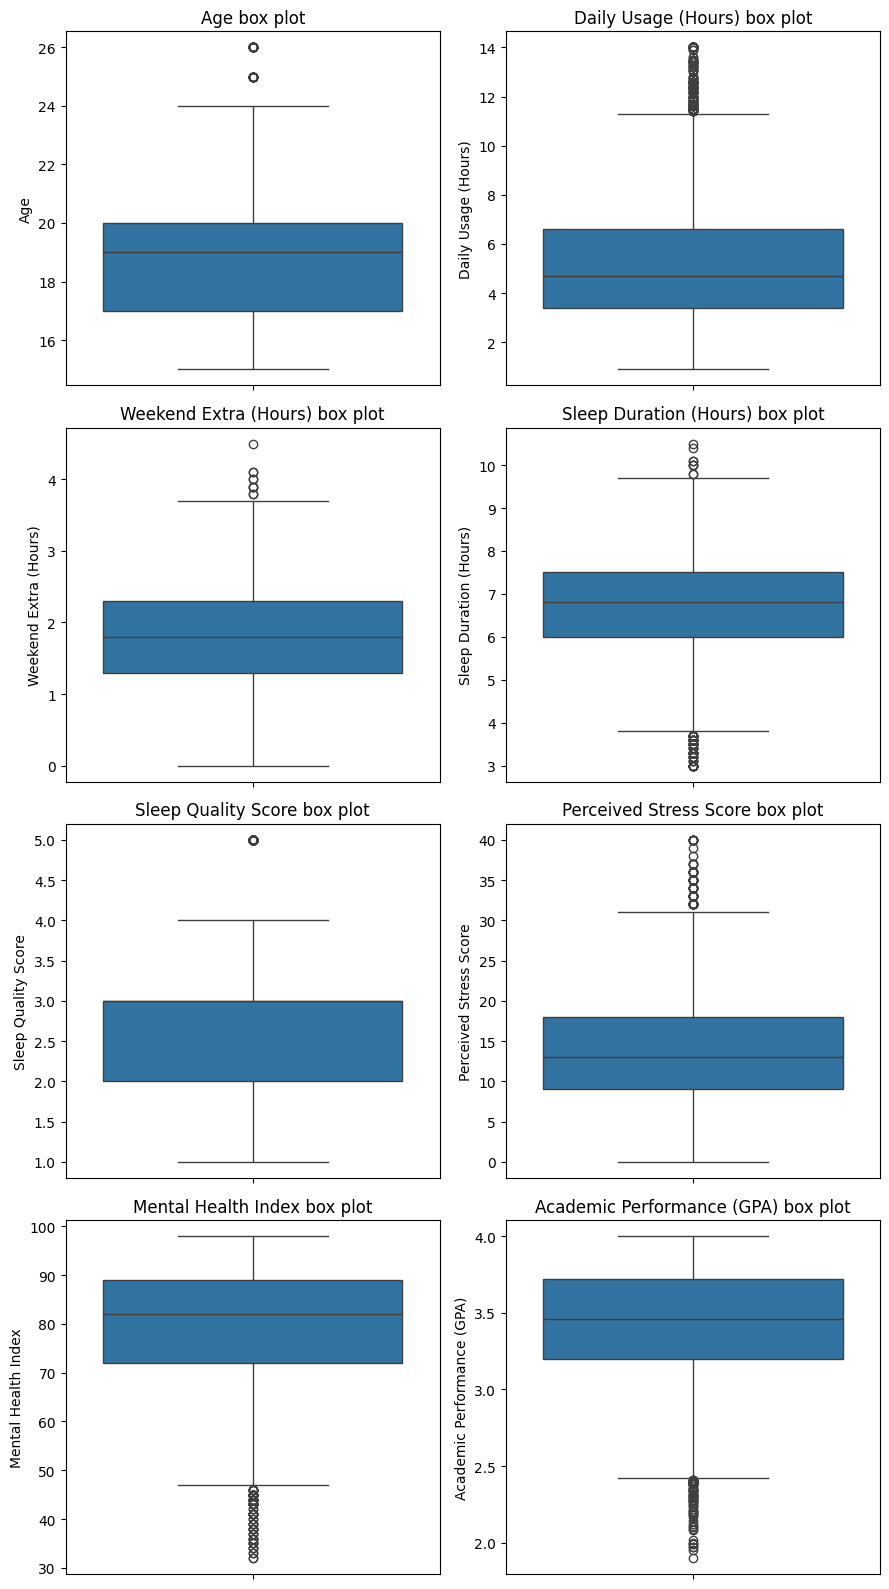

In [5]:
# 3.

graphs = {
    'Age' : df['Age'],
    'Daily Usage (Hours)' : df['Daily_Usage_Hours'],
    'Weekend Extra (Hours)' : df['Weekend_Extra_Hours'],
    'Sleep Duration (Hours)' : df['Sleep_Duration_Hours'],
    'Sleep Quality Score' : df['Sleep_Quality_Score'], 
    'Perceived Stress Score': df['Perceived_Stress_Score'], 
    'Mental Health Index' : df['Mental_Health_Index'],
    'Academic Performance (GPA)' : df['Academic_Performance_GPA']
}


fig, ax = plt.subplots(ncols=2, nrows=4, sharex=False, figsize=(9, 16))
ax = ax.flatten()

for graph, i in zip(graphs, range(0, 8)):
    ax[i].set_title(graph + ' box plot')
    sns.boxplot(data=graphs[graph], ax=ax[i])
    ax[i].set_ylabel(graph)

plt.tight_layout()
plt.show()

del fig, ax, graphs 

### 1.3 A3. Handling Missing Data (0.5)
Goal Apply multiple imputation strategies and compare effects.
#### Instructions
1. Introduce missing values artificially (e.g., 5% random NaN) or use a dataset with missing
values.
2. Apply three imputation methods:
 - Constant value,
 - Mean/Median/Mode,
 - Predictive imputation (e.g., regression or KNN).
3. Compare mean and standard deviation before and after imputation.
4. Briefly discuss advantages and disadvantages of each method.

In [6]:
rows_with_missing_values = df[df.isnull().any(axis=1)] # checking if there is already missing values

display(rows_with_missing_values)
# 131 rows with missing values, great

del rows_with_missing_values

,Student_ID,Age,Gender,Academic_Level,Primary_Platform,Daily_Usage_Hours,Weekend_Extra_Hours,Device_Type,Sleep_Duration_Hours,Sleep_Quality_Score,Late_Night_Usage,Social_Comparison_Frequency,Perceived_Stress_Score,Mental_Health_Index,Academic_Performance_GPA,Overall_Impact
39,STU_2024039,17,Male,High School,TikTok,3.3,1.7,Laptop/PC,6.0,1,False,Frequently,15.0,87,NaN,Beneficial
44,STU_2024044,21,Female,Undergraduate,Instagram,7.6,1.6,Smartphone,5.9,1,True,Rarely,25.0,70,NaN,Neutral
100,STU_2024100,19,Male,Undergraduate,Snapchat,6.4,2.7,Laptop/PC,5.4,1,True,Sometimes,16.0,67,NaN,Beneficial
104,STU_2024104,20,Male,Undergraduate,YouTube,3.2,3.0,Smartphone,6.4,2,False,Rarely,11.0,74,NaN,Beneficial
150,STU_2024150,17,Male,High School,Instagram,6.2,2.7,Smartphone,6.3,2,True,Always,17.0,70,NaN,Beneficial
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4380,STU_2028380,18,Female,High School,TikTok,4.7,2.2,Smartphone,6.7,3,False,Frequently,14.0,70,NaN,Beneficial
4412,STU_2028412,19,Male,Undergraduate,TikTok,4.0,2.8,Smartphone,7.6,3,True,Rarely,12.0,89,NaN,Beneficial
4425,STU_2028425,19,Male,Undergraduate,Instagram,12.4,1.2,Smartphone,5.8,1,True,Frequently,NaN,54,2.8,Neutral
4452,STU_2028452,24,Female,Undergraduate,YouTube,3.6,1.4,Laptop/PC,7.7,3,True,Frequently,11.0,92,NaN,Beneficial


In [7]:
# Numerical data preparation
numerical_nan = ['Perceived_Stress_Score', 'Academic_Performance_GPA'] # only columns with missing data

imputer = KNNImputer(n_neighbors=3) # receiving missing values by 
df_imputed = imputer.fit_transform(df[numerical_nan])
df_imputed = pd.DataFrame(df_imputed, columns=numerical_nan)

methods = {
    'Constant' : [2.5, 12],
    'Median' : [df['Academic_Performance_GPA'].median() , df['Perceived_Stress_Score'].median()],
    'KNN - imputed' : [df_imputed['Academic_Performance_GPA'], df_imputed['Perceived_Stress_Score']],
}

for method in methods:
    df_copy = df.copy()

    df_copy['Academic_Performance_GPA'] = df_copy['Academic_Performance_GPA'].fillna(methods[method][0])
    df_copy['Perceived_Stress_Score'] = df_copy['Perceived_Stress_Score'].fillna(methods[method][1])

    missing_cols = df_copy.columns[df_copy.isnull().any()] # checking NaNs
    rows_with_missing_values = df_copy[df_copy.isnull().any(axis=1)]  
    print(method.upper(), 'IMPUTATION METHOD\n')
    display('Amount of rows with missing data:', len(rows_with_missing_values), 'Columns containing NaN:', missing_cols)

    # Aggregating
    agg = df[numerical_nan].agg(['mean', 'std']).T
    agg_imputated = df_copy[numerical_nan].agg(['mean', 'std']).T

    print(f'before imputation with {method}: ')
    display(agg)
    print(f'after imputation with {method}:')
    display(agg_imputated)

CONSTANT IMPUTATION METHOD



'Amount of rows with missing data:'

0

'Columns containing NaN:'

Index([], dtype='object')

...

Index([], dtype='object')

before imputation with KNN - imputed: 


,mean,std
Perceived_Stress_Score,13.512124,7.072859
Academic_Performance_GPA,3.429282,0.392662


after imputation with KNN - imputed:


,mean,std
Perceived_Stress_Score,13.521111,7.057676
Academic_Performance_GPA,3.430850,0.391808


Each method did well. 

Advantage of Constant -- is speed, one can use literal zero, have minimal amount of computation to do, if it's not an outlier, main disadvantage is on small data or when nan is ~3-5% of all data, because it creates sufficient bias in dataset's statistics.

Advantage of Mean/Median -- is it has lesser bias than constant in large dataset, because of Law of Large Numbers.

Advantage of KNN -- in ordinal AND ordered data it will create unbiased result, though, can lead to a big bias, especially on not categorical, continous data, it may at least do standart error for mean larger.

### 2 Level B -- Medium
2.1 B1. Normalization & Standardization (0.5)

Goal Compare scaling methods.

Instructions
1. Select at least two numeric features with different scales.
2. Apply:
• Min–max normalization to [0,1],
• Z-score standardization.
3. Plot distributions before and after scaling.
4. Explain when each method is preferable

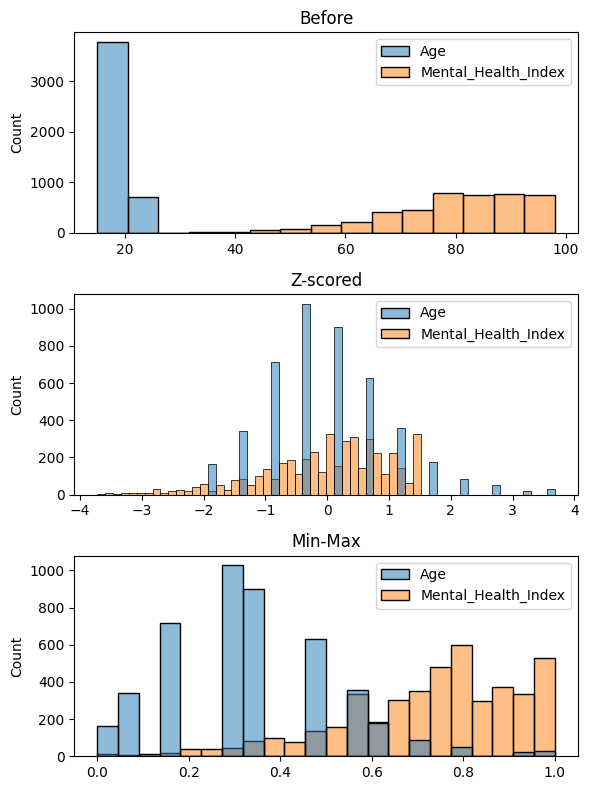

In [34]:
numeric = ['Age', 'Mental_Health_Index'] # Two numeric featuers
data = df[numeric]

# Min-Max normalization
mm_scaler = MinMaxScaler()
min_max = mm_scaler.fit_transform(data)
min_max = pd.DataFrame(min_max, columns=numeric)

# Z-score
s_scaler = StandardScaler()
z_scored = s_scaler.fit_transform(data)
z_scored = pd.DataFrame(z_scored, columns=numeric)

figures = {
    'Before' : df[numeric],
    'Z-scored' : z_scored,
    'Min-Max' : min_max
}

# Plot distributions
fig, ax = plt.subplots(nrows=3, figsize=(6, 8))
for figure, i in zip (figures, range (0, len(figures)) ):
    sns.histplot(data=figures[figure], ax=ax[i])
    ax[i].set_title(figure)

plt.tight_layout()
plt.show()

del numeric, data, mm_scaler, min_max, s_scaler, z_scored


As we can see, distributions didn't change, but scaling did.

Z-score is preferable, of course, when you have good evidence that your features is Normally Distributed with some estimated parameters (e.g., if you using Kolmogorov-Smirnov's, or Shapiro-Wilk's tests), then it will become golden in pursuing your goals. Especially it is good in working with algorithms assuming data is centered (PCA, SVM, Logistic Regression).

Min-Max is preferable when your data isn't normally distributed, and when you need a bounded range, e.g., inputs for Neural Networks.

### B2. Feature Creation & Discretization (0.75)
Goal Engineer useful features. Each task below (B2 task) independent and applies for different
features.

Instructions
1. Create one new feature using domain logic.
2. Apply discretization using (and after compare bin counts and boundaries):
- Equal-width binning,
- Equal-frequency binning.
3. Convert categorical variables using one-hot encoding.
4. Discuss how these transformations may impact ML models.

My domain logic is to analyze the real behaviour and to have an precise model to predict something linked with stress caused by social media.

In [9]:
# Engineering the new feature
domain = ['Daily_Usage_Hours', 'Perceived_Stress_Score']

df_copy = df.copy()
df_copy['DS_Coeff'] = df[domain[0]] * df[domain[1]] # DS_Coeff = Daily Usage * Perceived Stress, Daily-Stress coefficient
display(df_copy['DS_Coeff'])

# Discretization
e_width = pd.cut(x=df_copy['DS_Coeff'].astype(float), bins=4, labels=['Low', 'Medium', 'High', 'Very High']).to_frame() # equal-width binning
display(e_width)

e_freq = pd.qcut(x=df_copy['DS_Coeff'].astype(float), q=4, labels=['Very Low', 'Low', 'Medium', 'High']).to_frame() # equal 
display(e_freq)

# Ordinal Encoding
encoder = OrdinalEncoder()
e_width_encoded = encoder.fit_transform(e_width)
e_width_encoded = pd.DataFrame(data=e_width_encoded, columns=['DS_Coeff'])

e_freq_encoded = encoder.fit_transform(e_freq)
e_freq_encoded = pd.DataFrame(data=e_freq_encoded, columns=['DS_Coeff'])

display(e_width_encoded, e_freq_encoded)

0       150.0
1        78.2
2       196.2
3        90.0
4        52.8
        ...  
4495     63.8
4496     34.2
4497    100.1
4498    101.2
4499     18.0
Name: DS_Coeff, Length: 4500, dtype: float64

,DS_Coeff
0,Medium
1,Low
2,Medium
3,Low
4,Low
...,...
4495,Low
4496,Low
4497,Low
4498,Low


,DS_Coeff
0,High
1,Medium
2,High
3,Medium
4,Low
...,...
4495,Medium
4496,Low
4497,Medium
4498,Medium


,DS_Coeff
0,2.0
1,1.0
2,2.0
3,1.0
4,1.0
...,...
4495,1.0
4496,1.0
4497,1.0
4498,1.0


,DS_Coeff
0,0.0
1,2.0
2,0.0
3,2.0
4,1.0
...,...
4495,2.0
4496,1.0
4497,2.0
4498,2.0


I think equal frequency bin data can be more useful, because contains more information.

in this dataset, 25% of data for DS coeff can be labeled as high, while 25% is very low, and 25% of high contains information from 140 to 560 while very low is from 0 to 26. 
I think it can represent data correctly, while using real statistics.
While equal width bin is more useful in more uniformly distributed data. 

### 3 Additional Analytical Tasks

3.1 D1. Measures of Similarity and Dissimilarity (0.5)
Goal Understand distance and similarity metrics. Try to write calculation using Numpy (in
low code).

Instructions
1. Calculate Euclidean distance between two numeric vectors:
2. Compute Jaccard similarity between two sets:
3. Calculate between two numeric vectors:
• Cosine similarity,
• Pearson correlation coefficient.
4. Write a short explanation of each metric.
5. Compare numerical results and explain why they differ

In [ ]:
# Vectors 
numerical = ['Age', 'Daily_Usage_Hours', 'Weekend_Extra_Hours', 
             'Sleep_Duration_Hours', 'Sleep_Quality_Score', 'Perceived_Stress_Score', 
             'Mental_Health_Index', 'Academic_Performance_GPA']

first = df[numerical].loc[2]
second = df[numerical].loc[6]
display(first, second)

# Euclidean distance 
d = np.linalg.norm(first.values - second.values)
print('Euclidean distance between:', d)

del first, second, numerical, d

Age                         17.0
Daily_Usage_Hours           10.9
Weekend_Extra_Hours          1.7
Sleep_Duration_Hours         5.2
Sleep_Quality_Score          1.0
Perceived_Stress_Score      18.0
Mental_Health_Index         70.0
Academic_Performance_GPA     3.0
Name: 2, dtype: float64

Age                         20.00
Daily_Usage_Hours            5.60
Weekend_Extra_Hours          1.80
Sleep_Duration_Hours         8.30
Sleep_Quality_Score          3.00
Perceived_Stress_Score      10.00
Mental_Health_Index         88.00
Academic_Performance_GPA     3.72
Name: 6, dtype: float64

Euclidean distance between: 20.95777659963003


In [ ]:
# Sets
categories = ['Gender', 'Academic_Level', 'Primary_Platform', 'Late_Night_Usage']
first = pd.get_dummies(df[categories]).loc[2]
second = pd.get_dummies(df[categories]).loc[6]

set_first = set(first[first == True].index)
set_second = set(second[second == True].index)

# Jaccard Similarity
intersection = len(set_first.intersection(set_second))
union = len(set_first.union(set_second))

similarity = intersection/union if union > 0 else 0
display('Jaccard similarity:', similarity)

del categories, first, second, set_first, set_second, union, intersection, similarity

'Jaccard similarity:'

0.16666666666666666

Cosine similarity: 0.9871205392343626


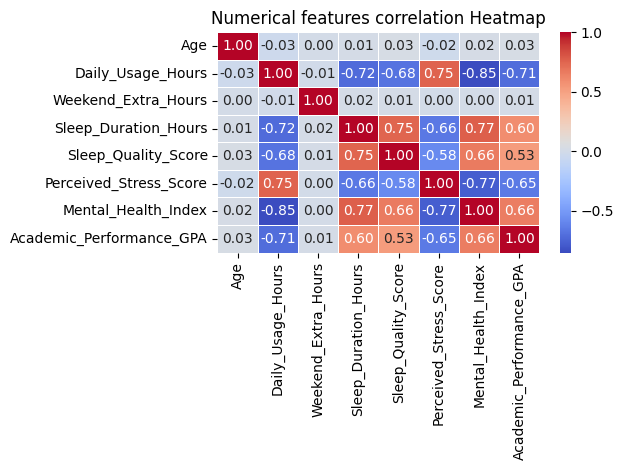

In [33]:
# Vectors
numerical = ['Age', 'Daily_Usage_Hours', 'Weekend_Extra_Hours', 
             'Sleep_Duration_Hours', 'Sleep_Quality_Score', 'Perceived_Stress_Score', 
             'Mental_Health_Index', 'Academic_Performance_GPA']

# Cosine similarity 
cosine = cosine_similarity(first, second)
print('Cosine similarity:', cosine[0][0])

# Pearson correlation coefficient 

matrix = df[numerical].corr()

fig = plt.figure()
sns.heatmap(matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Numerical features correlation Heatmap")
plt.tight_layout()

plt.show()

del numerical, fig, matrix, cosine

Euclidean distance is representation of how much do two vectors (rows, or notes about people in our case) is different in L_2 norm's sense.

Jaccard similarity is simple, intersection of sets (categorical features) divided by union, used to differ categorical features between two objects. 

Cosine similarity is more suitable for words embedded vectors, to see if some sentence differs from other, in numerical vectors it isn't so useful, Euclidean distance can be more suitable. 

Pearson's correlation coefficient is correlation between two factors, I decided to use a heatmap for my dataframe's numerical columns, and see all the correlations between them.

#### 3.2 D2. Dimensionality Reduction (PCA) (0.75)
Goal Apply Principal Component Analysis manually using NumPy.

Instructions
1. Standardize features.
2. Compute the covariance matrix.
3. Find eigenvalues and eigenvectors.
4. Select the two largest eigenvalues.
5. Project data onto the corresponding eigenvectors.
6. Plot the 2D result using matplotlib.
7. Briefly explain:
• What each step means,
• What eigenvalues represent,
• What the PCA visualization shows.
8. Compare the original data structure with the reduced 2D projection.


In [108]:
numerical = ['Age', 'Daily_Usage_Hours', 'Weekend_Extra_Hours', 
             'Sleep_Duration_Hours', 'Sleep_Quality_Score', 'Perceived_Stress_Score', 
             'Mental_Health_Index', 'Academic_Performance_GPA']

# scaling
data = df[numerical]


z_scored = (data - data.mean()) / data.std() # manual z_scored on estimated data parameters

z_scored['Academic_Performance_GPA'] = z_scored['Academic_Performance_GPA'].fillna(0) # filling NaN values with mean (0)
z_scored['Perceived_Stress_Score'] = z_scored['Perceived_Stress_Score'].fillna(0) 
# most of columns seems to be normally distributed, although I don't know if they are, and even if they are I don't know their parameters.

# Covariance matrix
cov_matrix = z_scored.T.dot(z_scored) / (len(z_scored) - 1) # because filling with mean is somewhat biased we don't get exact 1 for variance
print('Covariance matrix: ')
display(z_scored)

# Eigenvalues and Eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

sorted_index = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_index]
sorted_eigenvectors = eigenvectors[:, sorted_index]


print('Eigenvalues that has most variance')

display(sorted_eigenvalues)
display(sorted_eigenvectors)

Covariance matrix: 


,Age,Daily_Usage_Hours,Weekend_Extra_Hours,Sleep_Duration_Hours,Sleep_Quality_Score,Perceived_Stress_Score,Mental_Health_Index,Academic_Performance_GPA
0,0.149742,0.846254,-0.424522,-0.673391,-0.458037,0.917292,-0.533791,-1.780876
1,0.149742,-0.267205,-0.710544,1.007285,0.512381,0.493135,0.786491,-0.558450
2,-0.859756,2.151689,-0.138499,-1.261627,-1.428456,0.634521,-0.766781,-1.093262
3,-1.364505,0.270327,0.719570,0.755183,1.482799,0.210364,0.165182,-0.023639
4,-0.859756,-0.766341,1.148604,0.755183,1.482799,0.351750,0.320509,-0.049106
...,...,...,...,...,...,...,...,...
4495,-1.364505,0.193537,-0.853556,0.923251,0.512381,-0.355178,-0.067809,-1.475270
4496,0.149742,-0.574366,1.720650,-0.085154,0.512381,-0.637949,0.242845,-0.150975
4497,0.149742,0.923045,-0.996567,-0.589357,-0.458037,-0.072407,-0.533791,-0.685786
4498,-1.364505,-0.267205,2.149685,0.335015,0.512381,1.200063,0.553500,0.180099


Eigenvalues that has most variance


array([4.42611861, 1.00242558, 0.99719088, 0.54430432, 0.37484068,
       0.25246772, 0.24476809, 0.12876654])

array([[-0.01703896,  0.64848891,  0.76066735, -0.00400147,  0.0140945 ,
        -0.01092808, -0.01486086,  0.00143491],
       [ 0.43497197,  0.00418485, -0.00127821, -0.13511982, -0.10210533,
         0.1632744 , -0.62079435, -0.60831999],
       [-0.00628346,  0.76063445, -0.6486813 ,  0.01481463,  0.0174662 ,
         0.00710403,  0.00278559, -0.00505549],
       [-0.41387702, -0.00735312, -0.02391275, -0.397686  , -0.0115056 ,
        -0.45052327, -0.61390674,  0.29990113],
       [-0.38474884,  0.00854657, -0.00152095, -0.64680621, -0.31088068,
         0.50345969,  0.22823683, -0.17698644],
       [ 0.40288501,  0.0219607 , -0.00358525, -0.31664571, -0.50915358,
        -0.59450409,  0.34578998, -0.06841661],
       [-0.43624897, -0.01591817, -0.00244337,  0.05165138,  0.3299449 ,
        -0.40409182,  0.20901738, -0.70065506],
       [-0.37217499,  0.00413306,  0.00178032,  0.549602  , -0.72401008,
         0.00184027, -0.1488397 , -0.11426255]])

Most valuable eigenvalue has variance 4.426. Other one is going to be PC_2.

In [170]:
k = 2
projection_matrix = sorted_eigenvectors[:, :k]

projection = np.dot(z_scored, projection_matrix)
projection = pd.DataFrame(data=projection, columns=['PCA_1', 'PCA_2'])
display(projection)

,PCA_1,PCA_2
0,2.088369,-0.199940
1,-0.664931,-0.451502
2,3.020230,-0.635194
3,-0.725255,-0.327393
4,-1.188794,0.322459
...,...,...
4495,-0.030910,-1.548528
4496,-0.731863,1.389994
4497,1.284286,-0.652563
4498,-0.267282,0.769343


I read this article to see what is PCA: https://habr.com/ru/articles/507618/

1. Standardize features - we do this to scale normal data, because it is essential in PCA 
2. Computing the variance matrix - Covariance matrix multiplied by column of eigenvectors of covariance matrix, According to this article, is the solution to the matrix equation X * W^d = Z^d X is our matrix (vector-space) where W is some matrix (later it becomes eigenvectors matrix), matrix and Z is PCA reduced matrix (vector-space).

### 4 Level C — Difficult
4.1 C1. Advanced Sampling & Data Quality Analysis (1)
Goal Evaluate representativeness under different sampling schemes.

Instructions
1. Choose a public dataset with at least 20,000 rows, a meaningful categorical variable for
stratification, and a natural cluster identifier
2. Create:
(a) Simple Random Sample (10%),
(b) Stratified sample,
(c) Cluster sample (justify).
3. Compute descriptive statistics (mean, median, variance, IQR).
4. Visualize distributions vs. full dataset.


Cluster sample shape: (33840, 11)


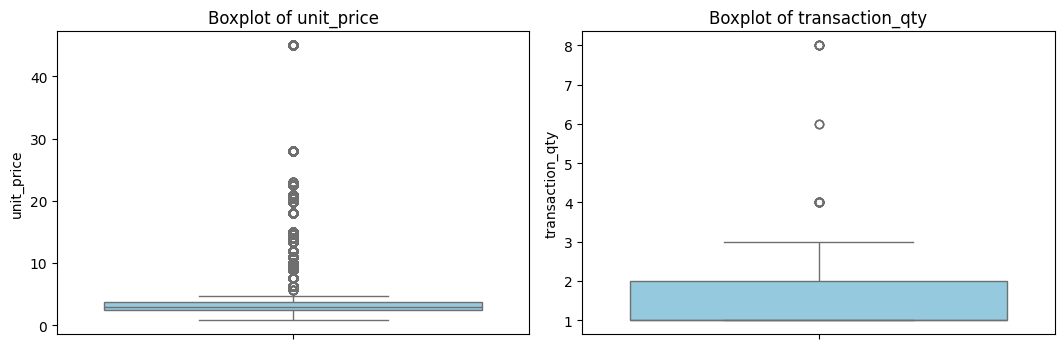

In [11]:
df = pd.read_excel('Coffee Shop Sales.xlsx')
numerical = ['unit_price', 'transaction_qty']

stratified_sample = df.groupby('store_location', group_keys=False).apply(lambda x: x.sample(frac=0.1), include_groups = False) # stratified by store location
# Cluster Sampling
cluster_col = 'product_id'

if cluster_col in df.columns:
    unique_clusters = df[cluster_col].unique()
    selected_clusters = np.random.choice(unique_clusters, size=int(len(unique_clusters) * 0.2), replace=False)
    
    cluster_sample = df[df[cluster_col].isin(selected_clusters)]
    print(f"Cluster sample shape: {cluster_sample.shape}")


# Boxplots for numeric columns to visualize outliers
plt.figure(figsize=(16, 10))
for i, col in enumerate(numerical, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()

plt.show()




In [12]:
# Finding and listing suspected outliers using IQR method
outliers_summary = {}

for col in numerical:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    outliers_summary[col] = {
        'count': len(outliers),
        'values': outliers.tolist()
    }
    print(f"Column '{col}': {len(outliers)} outliers found.")
    if len(outliers) > 0:
        print(f"  Outlier values: {outliers.values[:10]}... (total {len(outliers)})")

Column 'unit_price': 4212 outliers found.
  Outlier values: [ 8.95 21.   28.   28.   28.    6.4  19.75 12.   18.    9.5 ]... (total 4212)
Column 'transaction_qty': 36 outliers found.
  Outlier values: [4 4 8 8 4 4 4 4 4 4]... (total 36)
